In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

print(X.shape)

(300, 2)


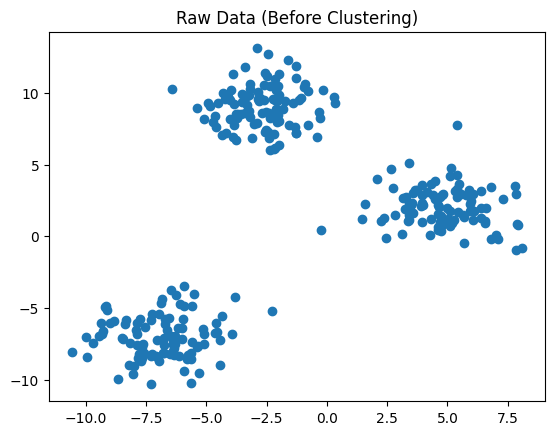

In [11]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Raw Data (Before Clustering)")
plt.show()

In [12]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [13]:
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

In [14]:
centroids = initialize_centroids(X, k=3)
print(centroids)

[[-8.65451496 -9.93895786]
 [-6.32972982 -8.28992927]
 [ 6.37704515  3.16066372]]


In [15]:
def assign_clusters(X, centroids):
    clusters = []
    
    for x in X:
        distances = [euclidean_distance(x, c) for c in centroids]
        cluster = np.argmin(distances)
        clusters.append(cluster)
    
    return np.array(clusters)

In [16]:
centroids = initialize_centroids(X, k=3)
labels = assign_clusters(X, centroids)

print(labels[:10])

[1 1 0 0 1 0 0 0 0 0]


In [17]:
print(np.unique(labels, return_counts=True))

(array([0, 1, 2]), array([200,  38,  62]))


In [ ]:
def update_centroids(X, labels, k):
    centroids = []
    
    for i in range(k):
        points = X[labels == i]
        
        if len(points) == 0:
            # Reinitialize randomly
            centroid = X[np.random.randint(len(X))]
        else:
            centroid = points.mean(axis=0)
        
        centroids.append(centroid)
    
    return np.array(centroids)

In [20]:
def kmeans(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)
    
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        
        new_centroids = update_centroids(X, labels, k)
        
        if np.allclose(centroids, new_centroids):
            break
        
        centroids = new_centroids
    
    return centroids, labels

In [21]:
centroids, labels = kmeans(X, k=3)

print(centroids)

[[-6.88599409 -7.03592142]
 [ 4.80071564  2.02930657]
 [-2.69525021  9.05821161]]


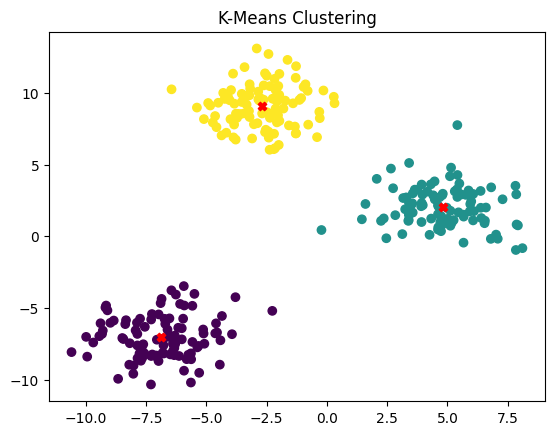

In [22]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X')

plt.title("K-Means Clustering")
plt.show()

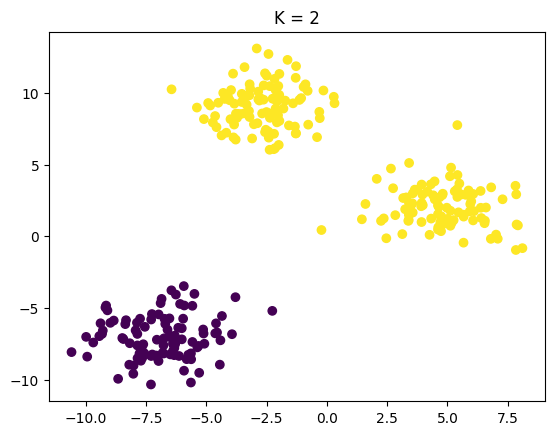

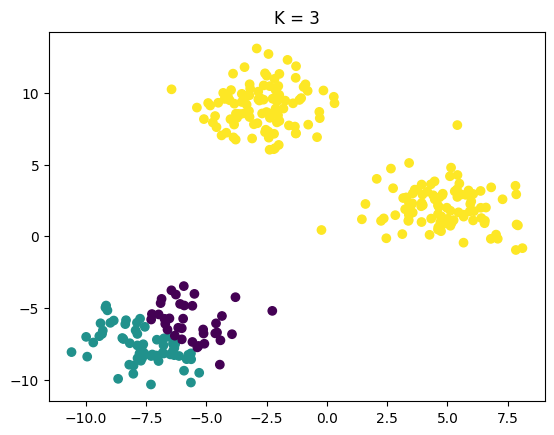

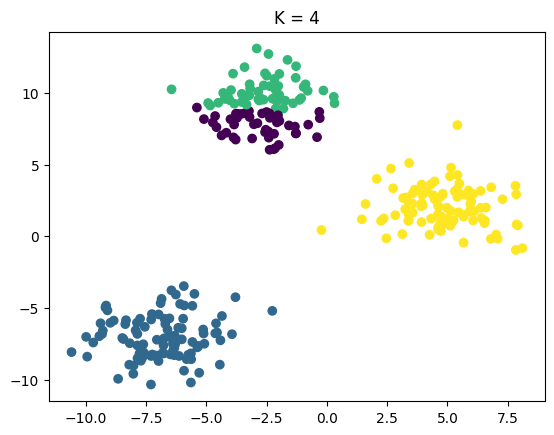

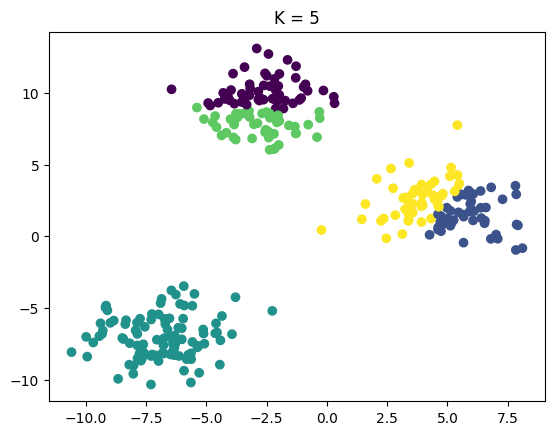

In [23]:
for k in [2, 3, 4, 5]:
    centroids, labels = kmeans(X, k)
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    plt.title(f"K = {k}")
    plt.show()

In [24]:
def compute_inertia(X, centroids, labels):
    inertia = 0
    
    for i, x in enumerate(X):
        centroid = centroids[labels[i]]
        inertia += np.sum((x - centroid) ** 2)
    
    return inertia